# PINN Introduction

#### The static, non-linear Euler-Bernoulli beam

---

Lecture: "Physics-Aware Machine Learning" @ Cyber-Physical Simulation, TU Darmstadt

Lecturer: Prof. Oliver Weeger

Content creators: Jasper O. Schommartz

Summer term 2025

---

#### In this notebook, you will...

* Define boundary conditions for a non-Linear Euler Bernoulli Beam (NLEBB)
* Define beam properties and generate data using numerical methods for training
* Define and train a Physics-Informed Neural Network to approximate the beam behaviour
* Evaluate and compare performance of the PINN-model with numerically generated data
* Use a mixed formulation to gauge its effects on model performance
* Discuss advantages, disadvantages and use case sccenarios of PINNs as compared to numerical methods like FEM
* Optionally, calibrate the PINN with modified boundary conditions

In [ ]:
# Run this cell is you are using Google Colab
!git clone https://github.com/CPSHub/LecturePhysicsAwareML.git
%cd LecturePhysicsAwareML/PINNs
%pip install -e .

In [ ]:
# Run this cell, if you are working locally
%cd ..
%pip install -e .

## Theory of the geometrically non-linear Euler-Bernoulli beam

![beam.png](attachment:beam.png)

The quasi-static behavior of the beam is described by the following set of partial differential equations (PDEs).

$$
- EA (u'' + w' w'') = f(x) \quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad\quad (1)
$$
$$
- EA (u'' w' + u' w'' + \frac{3}{2} w'' (w')^2) + EI w^{(4)} = q(x) \quad\quad(2)
$$

The first equation corresponds to horiontal balance of forces. It is a linear, second order PDE. The second equation corresponds to the vertical balance of forces, which is a nonlinear forth order PDE. The boundary value problem (BVP) for a cantilever beam is completed with the following set of Dirichlet and Neumann boundary conditions:

$$
u(0) = 0,\quad w(0) = 0,\quad w'(0) = 0
$$

$$
Q(L) = \hat{Q} = N w' + M',\quad M(L) = 0, \quad N(L) = 0.
$$

Here, $Q$, $N = EA (u' + 0.5 (w')^2)$ and $M = - E I w^{(4)}$ correspond to the resulting horizontal and vertical internal forces as well as the bending moment in the beam under the assumption of small angles, i.e., $\sin(\varphi) \approx w'$.

### Analytical solution

The BVP for the nonlinear cantilever beam can be solved analytically for $q(x) = f(x) = 0$. Inserting Eq.(1) in Eq.(2) simplifies Eq.(2) to

$$
- EA (u' w'' + w'' (w')^2) + EI w^{(4)} = q(x) \quad\quad(2^*).
$$

With $N(L) = 0$ we can conclude $N(x) = 0$ and Eq.($2^*$) simplifies even further to

$$
EI w^{(4)} = q(x) \quad\quad(2^{**}).
$$

Eq.($2^{**}$) exactly corresponds to the linear Euler-Bernoulli beam, which can be solved analytically before inserting the solution into Eq.(1).

#### Non-dimensionalization

For the calibration of a PINN it can be benefitial to non-dimensionalze the PDEs to assure that the constituents of the loss function are in similar orders of magnitude. Therefore, we introduce the non-dimensional variables $\hat{x}$ and $\hat{w}$ as

$$
x = x_c \cdot \hat{x},\quad u = u_c \cdot \hat{x}, \quad w = w_c \cdot \hat{x}
$$

By choosing $x_c = L$ and inserting the dimensionless into the PDEs the factors

$$
x_c = L,\quad u_c = \frac{I}{AL},\quad w_c = \sqrt{\frac{I}{A}}
$$

are obtained. The nondimensional system of PDEs now reads.

$$
- \hat{u}'' + \hat{w}' \hat{w}'' = \frac{x_c^2}{E A u_c} f(x_c \cdot \hat{x})
$$
$$
-\hat{w}'' \hat{u}' - \frac{3}{2} \hat{w}'' (\hat{w}')^2 - \hat{w}' \hat{u}'' + \hat{w}^{(4)} = \frac{x_c^3}{E A w_c u_c} q(x_c \cdot \hat{x})
$$

For the implementation we set $q(x)= f(x) = 0$. The nondimensional boundary conditions are

$$
\hat{u}(0) = 0,\quad \hat{w}(0) = 0,\quad \hat{w}'(0) = 0
$$

$$
\frac{Q(L)}{\hat{Q}} - 1 = 0,\quad \hat{w}''(0) = 0, \quad N(L) \frac{x_c}{EA u_c} = 0.
$$

### Define boundary conditions.

In [2]:
import jax.numpy as jnp
from paml_pinns.nlebb import Config, get_data_decorator


@get_data_decorator
def get_data(config: Config):
    if config.bc_case == 0:
        u_bc_coords = jnp.array([0.0])
        u_bc_values = jnp.array([0.0])
        w_bc_coords = jnp.array([0.0])
        w_bc_values = jnp.array([0.0])
        w_x_bc_coords = jnp.array([0.0])
        w_x_bc_values = jnp.array([0.0])
        N_bc_coords = jnp.array([config.L])
        N_bc_values = jnp.array([0.0])
        M_bc_coords = jnp.array([config.L])
        M_bc_values = jnp.array([0.0])
        Q_bc_coords = jnp.array([config.L])
        Q_bc_values = jnp.array([config.F])
    else:
        NotImplementedError(
            "Data generation is not implemented for these boundary conditions."
        )

    bc = {
        "u_bc_coords": u_bc_coords,
        "u_bc_values": u_bc_values,
        "w_bc_coords": w_bc_coords,
        "w_bc_values": w_bc_values,
        "w_x_bc_coords": w_x_bc_coords,
        "w_x_bc_values": w_x_bc_values,
        "N_bc_coords": N_bc_coords,
        "N_bc_values": N_bc_values,
        "M_bc_coords": M_bc_coords,
        "M_bc_values": M_bc_values,
        "Q_bc_coords": Q_bc_coords,
        "Q_bc_values": Q_bc_values,
    }
    return bc


### Configure beam properties.

In [3]:
from paml_pinns.nlebb import get_config_decorator
from typing import Tuple


@get_config_decorator
def get_config(bc_case: int) -> Tuple[float, float, float, float, float, float]:
    if bc_case == 0:
        E = 1.0
        A = 1.0
        II = 1.0
        L = 1.0
        F = 1.0
        f = 0.0
        q = 0.0
    else:
        NotImplementedError(
            "No configuration implemented for these boundary conditions."
        )

    return E, A, II, L, F, f, q

### Data generation and model creation
![PINN beam](PINN_beam.png)

In [4]:
import jax
from paml_pinns.nlebb import create_pinn


config = get_config(bc_case=0)
x, y, bc, params = get_data(config)

key = jax.random.PRNGKey(1234)
model = create_pinn(params, bc, key=key, mixed_formulation=False)
weights = {"u": 1.0, "w": 1.0, "w_x": 1.0, "N": 1.0, "M": 1.0, "Q": 1.0}
params

{'L': 1.0, 'EA': 1.0, 'EI': 1.0, 'f0': 0.0, 'q0': 0.0}

### Calibration and Evaluation

Step: 0,	Loss: 1.1403616666793823
Step: 1000,	Loss: 0.00015839705883990973
Step: 2000,	Loss: 8.093729411484674e-05
Step: 3000,	Loss: 2.5518877009744756e-05
Step: 4000,	Loss: 1.5645586245227605e-05
Step: 5000,	Loss: 2.9464545150403865e-05
Step: 6000,	Loss: 7.07950493961107e-06
Step: 7000,	Loss: 8.969462214736268e-05
Step: 8000,	Loss: 7.1106760515249334e-06
Step: 9000,	Loss: 8.186557352019008e-06
Step: 10000,	Loss: 2.4338644379895413e-06
Step: 11000,	Loss: 6.876647603348829e-06
Step: 12000,	Loss: 5.344776127458317e-06
Step: 13000,	Loss: 1.663197690504603e-05
Step: 14000,	Loss: 8.332772267749533e-06
Step: 15000,	Loss: 9.65796789387241e-06
Step: 16000,	Loss: 1.9631766008387785e-06
Step: 17000,	Loss: 2.0224129912094213e-05
Step: 18000,	Loss: 2.6860489015234634e-06
Step: 19000,	Loss: 6.618820862058783e-06
Step: 20000,	Loss: 1.4720755643793382e-05
Step: 21000,	Loss: 7.96254062152002e-06
Step: 22000,	Loss: 1.6763964367783046e-06
Step: 23000,	Loss: 7.031611858110409e-06
Step: 24000,	Loss: 7.258

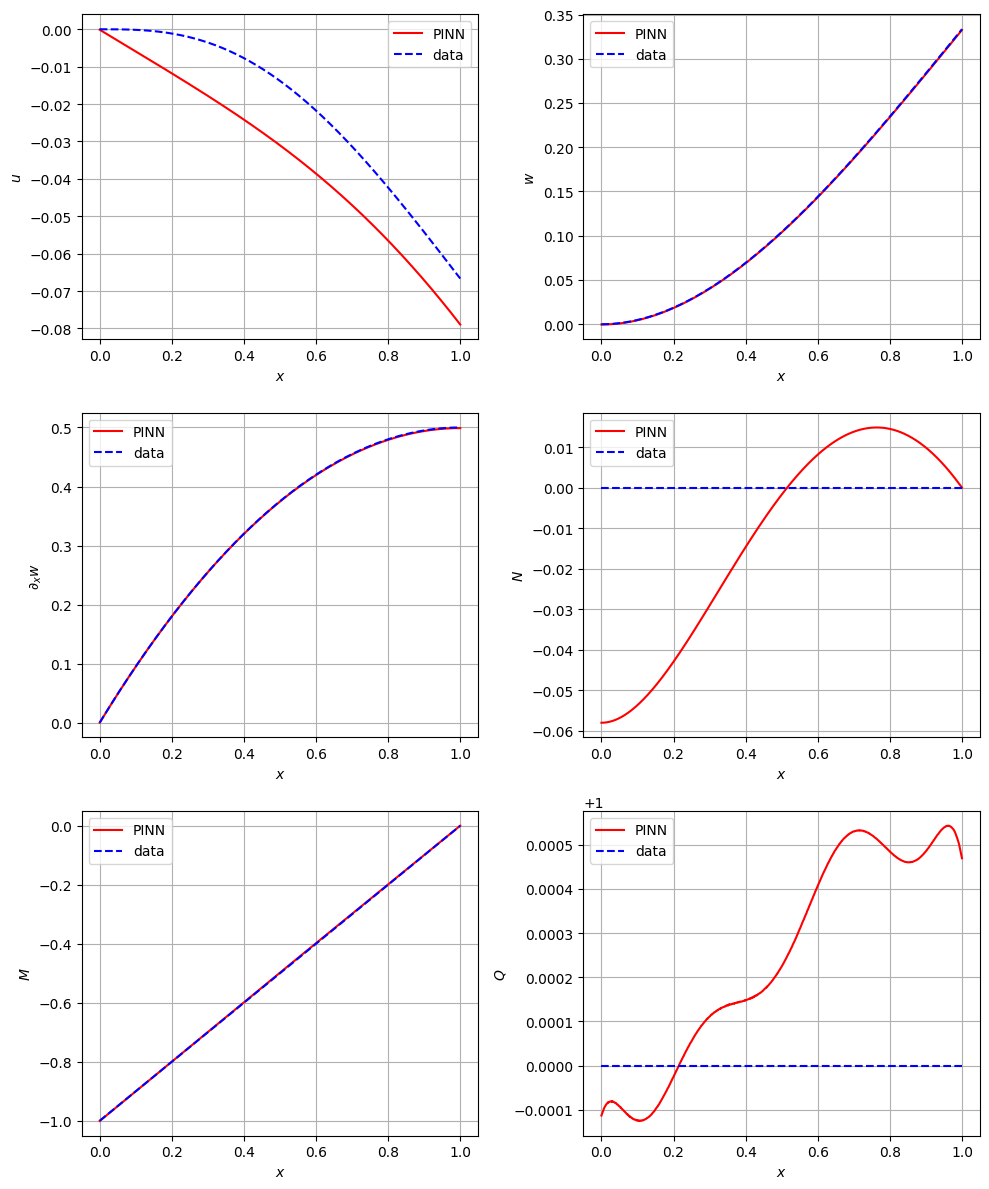

In [5]:
from paml_pinns import train
from paml_pinns.nlebb import evaluate

model = train(model, x, weights, steps=50_000, batch_size=128)
evaluate(model, x, y)

Tasks
=====

#### Task 1: Mixed formulation

For `bc_case=0`, ...

a) Set `mixed_formulation=False`. Can the model approximate the solution?

b) Now set `mixed_formulation=True`, while keeping all other parameters the same. Can the model approximate the solution now? How can the observed differences be explained?

c) Next select your preferred architecture and increase the value of `E`. What do you observe? How could the effects be mitigated?

#### Task 2: Discussion

Based on your experience from the the PINN task, collect some advantages and disadvantages of PINNs over traditional numerical methods like FEM. When would you prefer to use PINNs, when would you opt for FEM? Discuss your thoughts with a partner.

#### Task 3 (Optional): Implementation of different boundary conditions

Calibrate the PINN to different boundary conditions by modifying the `get_data`
function and the `paml_pinn.nlebb.cases` module. Can you find an analytical soulution to validate your implementation?